In [1]:
from pathlib import Path

train_dir = Path("data/Training")
test_dir = Path("data/Testing")

print("Training exists:", train_dir.exists())
print("Testing exists:", test_dir.exists())

Training exists: True
Testing exists: True


In [2]:
classes = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Classes:", classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for class_name in classes:
    train_count = sum(
        1
        for f in (train_dir / class_name).iterdir()
        if f.suffix.lower() in image_extensions
    )

    test_count = sum(
        1
        for f in (test_dir / class_name).iterdir()
        if f.suffix.lower() in image_extensions
    )

    print(
        f"{class_name:12} "
        f"Train: {train_count:5} "
        f"Test: {test_count:5}"
    )

glioma       Train:  1400 Test:   400
meningioma   Train:  1400 Test:   400
notumor      Train:  1400 Test:   400
pituitary    Train:  1400 Test:   400


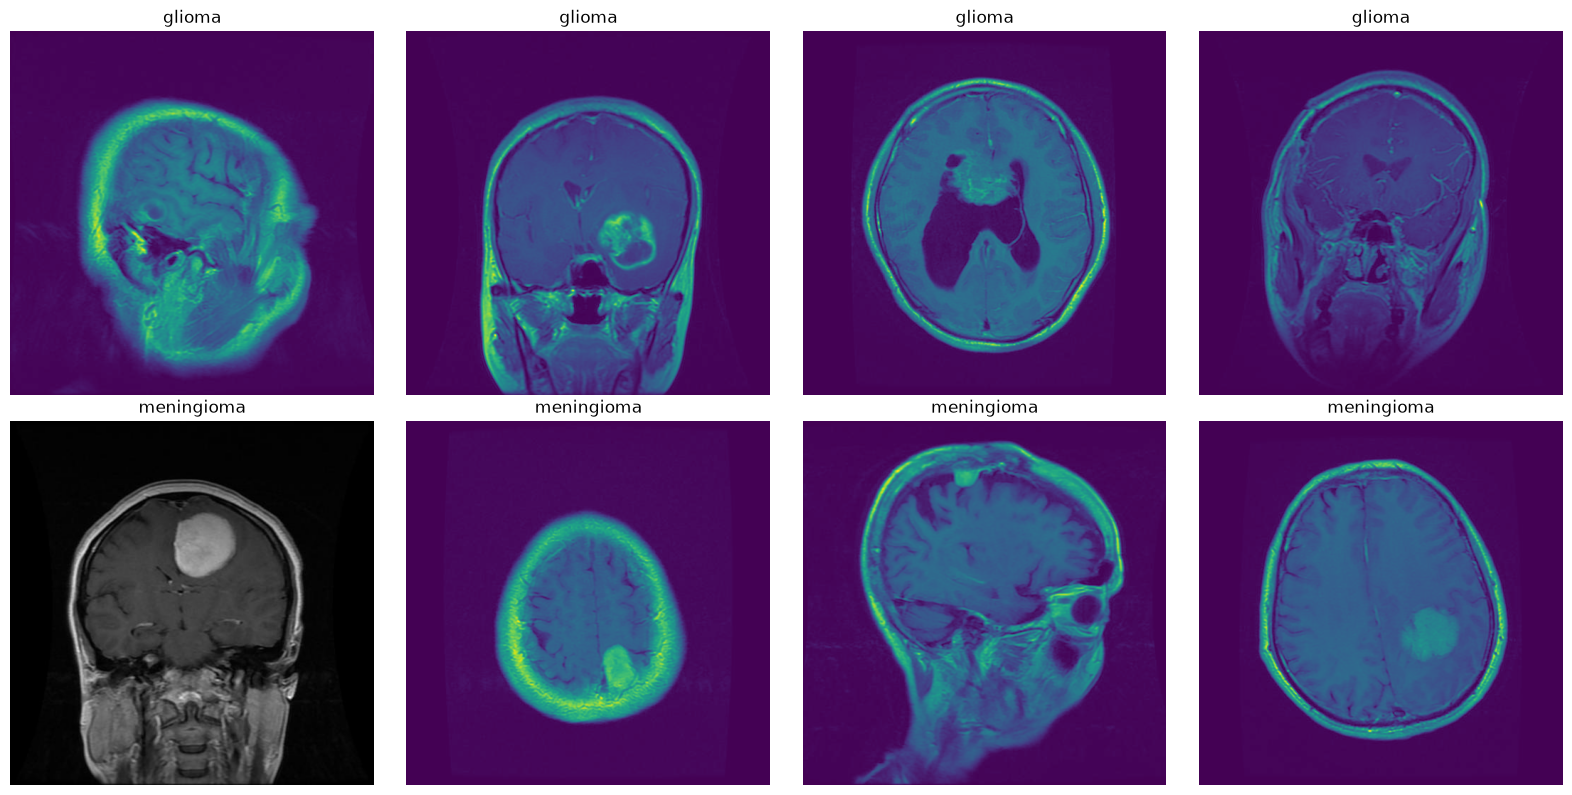

In [4]:
# visualize the image
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, class_name in enumerate(classes[:2]):
    image_files = list((train_dir / class_name).glob("*"))
    
    for col in range(4):
        image_path = random.choice(image_files)
        image = Image.open(image_path)
        
        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# inspect image dimensions
for class_name in classes:
    image_files = list((train_dir / class_name).glob("*"))
    
    image_path = image_files[0]
    image = Image.open(image_path)
    
    print(
        class_name,
        "size:", image.size,
        "mode:", image.mode
    )

glioma size: (512, 512) mode: L
meningioma size: (512, 512) mode: RGB
notumor size: (201, 251) mode: RGB
pituitary size: (512, 512) mode: RGB


In [6]:
from collections import Counter
from PIL import Image

size_counter = Counter()
mode_counter = Counter()

for class_name in classes:
    class_dir = train_dir / class_name

    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            try:
                with Image.open(image_path) as img:
                    size_counter[img.size] += 1
                    mode_counter[img.mode] += 1
            except Exception as e:
                print("Problem:", image_path, e)

print("Image modes:")
for mode, count in mode_counter.items():
    print(mode, ":", count)

print("\nMost common image sizes:")
for size, count in size_counter.most_common(10):
    print(size, ":", count)

Image modes:
L : 2358
RGB : 3238
RGBA : 3
P : 1

Most common image sizes:
(512, 512) : 4012
(225, 225) : 253
(630, 630) : 69
(201, 251) : 40
(236, 236) : 39
(442, 442) : 38
(150, 198) : 33
(232, 217) : 32
(228, 221) : 32
(428, 417) : 31


In [7]:
# create pytorch transform
import torch
from torchvision import transforms

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.14.0+cu126
CUDA: True


In [59]:
# training and testing transforms
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [60]:
# load dataset
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)
print("Training:", len(train_dataset))
print("Testing:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Training: 5600
Testing: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [61]:
# check tranform image
image, label = train_dataset[0]

print("Shape:", image.shape)
print("Label:", label)
print("Datatype:", image.dtype)

Shape: torch.Size([3, 224, 224])
Label: 0
Datatype: torch.float32


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].


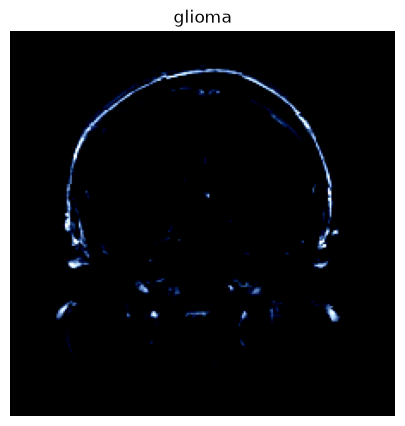

In [62]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

image = image.permute(1, 2, 0)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [63]:
# split the data for training and validation
from torch.utils.data import random_split

# Dataset without augmentation for creating the split
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=None
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_subset))
print("Validation:", len(val_subset))

Training: 4480
Validation: 1120


In [64]:
from torch.utils.data import Subset

train_dataset = Subset(
    datasets.ImageFolder(
        root=train_dir,
        transform=train_transform
    ),
    train_subset.indices
)

val_dataset = Subset(
    datasets.ImageFolder(
        root=train_dir,
        transform=test_transform
    ),
    val_subset.indices
)

In [65]:
# create data loaders
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 280
Validation batches: 70
Test batches: 100


In [66]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])


Build first CNN

In [67]:
import torch
import torch.nn as nn

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [69]:
# Define CNN
class BrainTumorCNN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [70]:
#create the model
model = BrainTumorCNN(num_classes=4)

model = model.to(device)

print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [71]:
# count parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 101764
Trainable parameters: 101764


In [72]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 4])


In [73]:
# loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [74]:
# write training loop
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [75]:
# validate function
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [76]:
# train for the first time
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 15

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] Train Loss: 1.1562 Train Acc: 0.4741 Val Loss: 1.0508 Val Acc: 0.6018
Epoch [2/15] Train Loss: 1.0743 Train Acc: 0.5388 Val Loss: 1.0871 Val Acc: 0.5134
Epoch [3/15] Train Loss: 1.0108 Train Acc: 0.5906 Val Loss: 0.9396 Val Acc: 0.6429
Epoch [4/15] Train Loss: 0.9292 Train Acc: 0.6460 Val Loss: 0.9069 Val Acc: 0.6259
Epoch [5/15] Train Loss: 0.8523 Train Acc: 0.6772 Val Loss: 0.7344 Val Acc: 0.7286
Epoch [6/15] Train Loss: 0.8060 Train Acc: 0.7036 Val Loss: 0.6815 Val Acc: 0.7661
Epoch [7/15] Train Loss: 0.7490 Train Acc: 0.7203 Val Loss: 0.6873 Val Acc: 0.7518
Epoch [8/15] Train Loss: 0.7067 Train Acc: 0.7346 Val Loss: 0.6786 Val Acc: 0.7402
Epoch [9/15] Train Loss: 0.6736 Train Acc: 0.7556 Val Loss: 0.5896 Val Acc: 0.7973
Epoch [10/15] Train Loss: 0.6436 Train Acc: 0.7674 Val Loss: 0.5781 Val Acc: 0.7982
Epoch [11/15] Train Loss: 0.6388 Train Acc: 0.7777 Val Loss: 0.5622 Val Acc: 0.7830
Epoch [12/15] Train Loss: 0.6109 Train Acc: 0.7842 Val Loss: 0.5430 Val Acc: 0.8045
E

In [77]:
ice = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [78]:
from torchvision import models
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\91988/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [79]:
for param in resnet.parameters():
    param.requires_grad = False

In [81]:
resnet.fc = nn.Linear(512, 4)

In [83]:
resnet = resnet.to(device)
print(resnet.fc)

Linear(in_features=512, out_features=4, bias=True)


In [84]:
# check traiable parameters
trainable_params = sum(
    p.numel() for p in resnet.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in resnet.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 2052
Total parameters: 11178564


In [85]:
# loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=0.001
)

In [86]:
resnet.fc.parameters()

<generator object Module.parameters at 0x000001D255CCE420>

In [87]:
print("Device:", device)
print(resnet.fc)
print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Device: cuda
Linear(in_features=512, out_features=4, bias=True)
Trainable parameters: 2052
Total parameters: 11178564


In [88]:
# trainresnet18
train_history = []
val_history = []

num_epochs = 10

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        resnet,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        resnet,
        val_loader,
        criterion,
        device
    )

    train_history.append({
        "loss": train_loss,
        "acc": train_acc
    })

    val_history.append({
        "loss": val_loss,
        "acc": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] Train Loss: 0.6922 Train Acc: 0.7451 Val Loss: 0.4405 Val Acc: 0.8536
Epoch [2/10] Train Loss: 0.4819 Train Acc: 0.8221 Val Loss: 0.4110 Val Acc: 0.8500
Epoch [3/10] Train Loss: 0.4193 Train Acc: 0.8391 Val Loss: 0.3852 Val Acc: 0.8580
Epoch [4/10] Train Loss: 0.4029 Train Acc: 0.8500 Val Loss: 0.3326 Val Acc: 0.8830
Epoch [5/10] Train Loss: 0.3869 Train Acc: 0.8536 Val Loss: 0.3140 Val Acc: 0.8848
Epoch [6/10] Train Loss: 0.3676 Train Acc: 0.8636 Val Loss: 0.3004 Val Acc: 0.8964
Epoch [7/10] Train Loss: 0.3624 Train Acc: 0.8667 Val Loss: 0.3551 Val Acc: 0.8571
Epoch [8/10] Train Loss: 0.3538 Train Acc: 0.8627 Val Loss: 0.3309 Val Acc: 0.8777
Epoch [9/10] Train Loss: 0.3589 Train Acc: 0.8654 Val Loss: 0.2814 Val Acc: 0.8920
Epoch [10/10] Train Loss: 0.3556 Train Acc: 0.8658 Val Loss: 0.2998 Val Acc: 0.8911


In [89]:
torch.save(
    resnet.state_dict(),
    "models/resnet18_frozen_best.pth"
)

In [91]:
# load best restnet18 weights
resnet.load_state_dict(
    torch.load(
        "models/resnet18_frozen_best.pth",
        map_location=device
    )
)

resnet = resnet.to(device)

print("Best ResNet18 weights loaded.")

Best ResNet18 weights loaded.


In [92]:
# unfreeze the last two layers of ResNet18 3 and 4
for param in resnet.layer3.parameters():
    param.requires_grad = True

for param in resnet.layer4.parameters():
    param.requires_grad = True

for param in resnet.fc.parameters():
    param.requires_grad = True

In [93]:
#check trainable parameters
trainable_params = sum(
    p.numel() for p in resnet.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in resnet.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 10495492
Total parameters: 11178564


In [94]:
#create new optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=0.0001
)

In [95]:
# train for 10 epochs
train_history_ft = []
val_history_ft = []

num_epochs = 10

best_val_acc = 0.0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        resnet,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        resnet,
        val_loader,
        criterion,
        device
    )

    train_history_ft.append({
        "loss": train_loss,
        "acc": train_acc
    })

    val_history_ft.append({
        "loss": val_loss,
        "acc": val_acc
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            resnet.state_dict(),
            "models/resnet18_finetuned_best.pth"
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/10] Train Loss: 0.2859 Train Acc: 0.9009 Val Loss: 0.1553 Val Acc: 0.9446
Epoch [2/10] Train Loss: 0.1381 Train Acc: 0.9520 Val Loss: 0.1316 Val Acc: 0.9509
Epoch [3/10] Train Loss: 0.0804 Train Acc: 0.9741 Val Loss: 0.1245 Val Acc: 0.9571
Epoch [4/10] Train Loss: 0.0846 Train Acc: 0.9734 Val Loss: 0.0686 Val Acc: 0.9759
Epoch [5/10] Train Loss: 0.0481 Train Acc: 0.9833 Val Loss: 0.1043 Val Acc: 0.9589
Epoch [6/10] Train Loss: 0.0433 Train Acc: 0.9855 Val Loss: 0.0521 Val Acc: 0.9795
Epoch [7/10] Train Loss: 0.0348 Train Acc: 0.9871 Val Loss: 0.0466 Val Acc: 0.9830
Epoch [8/10] Train Loss: 0.0409 Train Acc: 0.9859 Val Loss: 0.0591 Val Acc: 0.9812
Epoch [9/10] Train Loss: 0.0496 Train Acc: 0.9839 Val Loss: 0.0551 Val Acc: 0.9812
Epoch [10/10] Train Loss: 0.0307 Train Acc: 0.9904 Val Loss: 0.0541 Val Acc: 0.9875

Best Validation Accuracy: 0.9875


In [96]:
# load best model
best_model = models.resnet18(
    weights=None
)

best_model.fc = nn.Linear(512, 4)

best_model.load_state_dict(
    torch.load(
        "models/resnet18_finetuned_best.pth",
        map_location=device
    )
)

best_model = best_model.to(device)

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [97]:
# evaluate on test set
def get_predictions(model, loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return all_labels, all_predictions

In [98]:
y_true, y_pred = get_predictions(
    best_model,
    test_loader,
    device
)

In [99]:
print("Number of test samples:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of test samples: 1600
Number of predictions: 1600


In [100]:
# calculate test accurecy
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.9519
Test Accuracy: 95.19%


In [101]:
# classification report
from sklearn.metrics import classification_report

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9881    0.8325    0.9037       400
  meningioma     0.9076    0.9825    0.9436       400
     notumor     0.9368    1.0000    0.9674       400
   pituitary     0.9851    0.9925    0.9888       400

    accuracy                         0.9519      1600
   macro avg     0.9544    0.9519    0.9508      1600
weighted avg     0.9544    0.9519    0.9508      1600



In [102]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[333  40  24   3]
 [  3 393   1   3]
 [  0   0 400   0]
 [  1   0   2 397]]


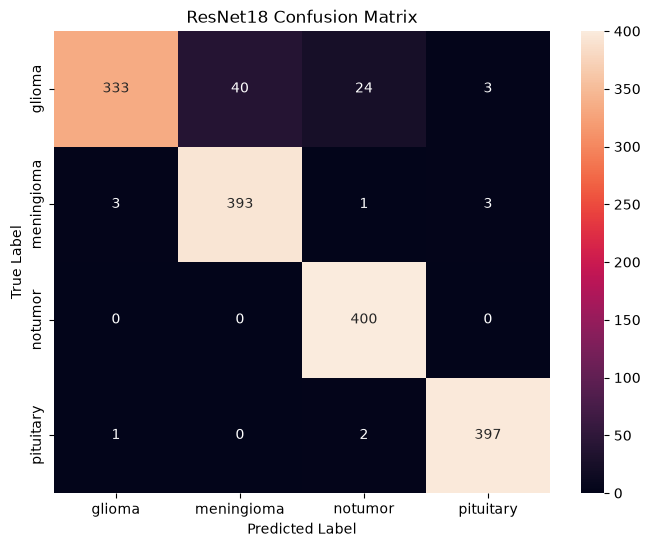

In [103]:
import seaborn as sns
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 Confusion Matrix")

plt.show()

In [104]:
# import grad cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import numpy as np
import matplotlib.pyplot as plt

In [105]:
target_layers = [best_model.layer4[-1]]

In [106]:
image, label = test_dataset[0]

print("Image shape:", image.shape)
print("True label:", class_names[label])

Image shape: torch.Size([3, 224, 224])
True label: glioma


In [108]:
# denormalize the image
# ImageNet normalization values
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Denormalize
img_display = image.cpu() * std + mean

# Clamp values to valid image range
img_display = img_display.clamp(0, 1)

# Convert from [C, H, W] → [H, W, C]
img_display = img_display.permute(1, 2, 0).numpy()

print("Display image shape:", img_display.shape)
print("Pixel range:", img_display.min(), img_display.max())

Display image shape: (224, 224, 3)
Pixel range: 0.0 0.9960785


In [109]:
# get model prediction
best_model.eval()

input_tensor = image.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = best_model(input_tensor)

probabilities = torch.softmax(outputs, dim=1)

predicted_class = outputs.argmax(dim=1).item()
confidence = probabilities[0, predicted_class].item()

print("True class:", class_names[label])
print("Predicted class:", class_names[predicted_class])
print(f"Confidence: {confidence * 100:.2f}%")

True class: glioma
Predicted class: glioma
Confidence: 74.91%


In [111]:
# create gradcam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
target_layers = [best_model.layer4[-1]]

cam = GradCAM(
    model=best_model,
    target_layers=target_layers
)


In [112]:
targets = [
    ClassifierOutputTarget(predicted_class)
]

In [113]:
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

In [114]:
visualization = show_cam_on_image(
    img_display,
    grayscale_cam,
    use_rgb=True
)

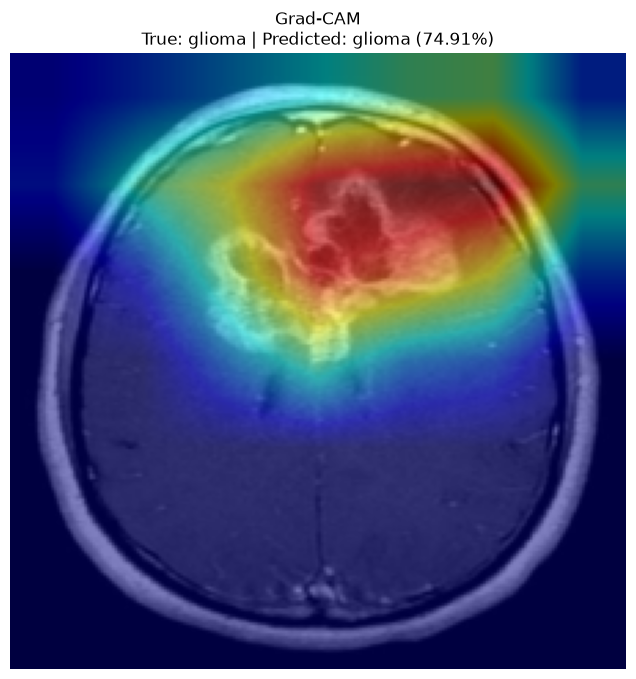

In [115]:
plt.figure(figsize=(8, 8))

plt.imshow(visualization)

plt.title(
    f"Grad-CAM\n"
    f"True: {class_names[label]} | "
    f"Predicted: {class_names[predicted_class]} "
    f"({confidence * 100:.2f}%)"
)

plt.axis("off")
plt.show()

In [117]:
# misclassified glioma
# Find a misclassified glioma
misclassified_index = None

for i in range(len(test_dataset)):
    image_i, label_i = test_dataset[i]

    # Only look at actual glioma images
    if label_i == class_names.index("glioma"):

        input_i = image_i.unsqueeze(0).to(device)

        with torch.no_grad():
            output_i = best_model(input_i)

        pred_i = output_i.argmax(dim=1).item()

        if pred_i != label_i:
            misclassified_index = i
            break

print("Misclassified index:", misclassified_index)

Misclassified index: 5


In [118]:
image_mis, label_mis = test_dataset[misclassified_index]

input_mis = image_mis.unsqueeze(0).to(device)

with torch.no_grad():
    output_mis = best_model(input_mis)

prob_mis = torch.softmax(output_mis, dim=1)

pred_mis = output_mis.argmax(dim=1).item()
conf_mis = prob_mis[0, pred_mis].item()

print("True class:", class_names[label_mis])
print("Predicted class:", class_names[pred_mis])
print(f"Confidence: {conf_mis * 100:.2f}%")

True class: glioma
Predicted class: notumor
Confidence: 75.48%


In [119]:
# Prepare the misclassified image
image_mis, label_mis = test_dataset[misclassified_index]

input_mis = image_mis.unsqueeze(0).to(device)

# Target the layer we used previously
target_layers = [best_model.layer4[-1]]

# Create Grad-CAM
cam = GradCAM(
    model=best_model,
    target_layers=target_layers
)

# Explain the model's predicted class
targets = [
    ClassifierOutputTarget(pred_mis)
]

# Generate heatmap
grayscale_cam = cam(
    input_tensor=input_mis,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

In [121]:
# denormilize image
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

img_mis_display = image_mis.cpu() * std + mean

img_mis_display = img_mis_display.clamp(0, 1)

img_mis_display = (
    img_mis_display
    .permute(1, 2, 0)
    .numpy()
)

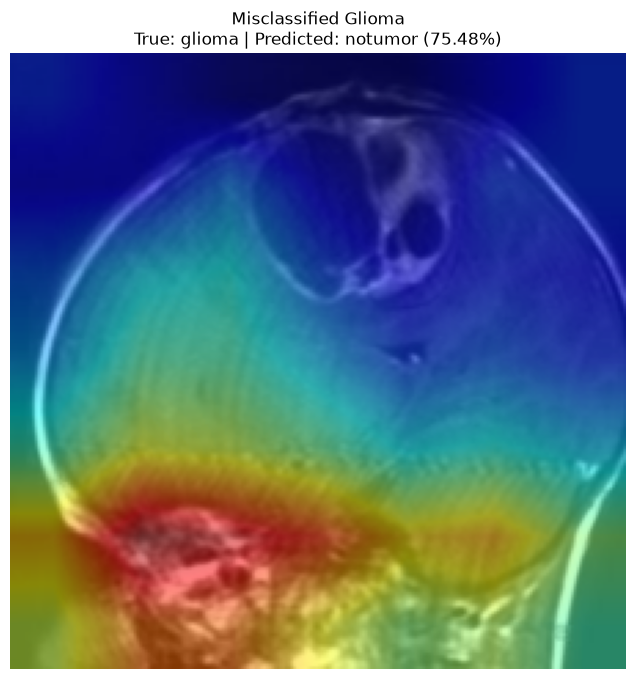

In [122]:
# overlay grad cam
visualization_mis = show_cam_on_image(
    img_mis_display,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8, 8))

plt.imshow(visualization_mis)

plt.title(
    f"Misclassified Glioma\n"
    f"True: {class_names[label_mis]} | "
    f"Predicted: {class_names[pred_mis]} "
    f"({conf_mis * 100:.2f}%)"
)

plt.axis("off")
plt.show()


In [123]:
# optimize all golima errors
import numpy as np

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

glioma_idx = class_names.index("glioma")
meningioma_idx = class_names.index("meningioma")
notumor_idx = class_names.index("notumor")

glioma_to_meningioma = np.where(
    (y_true_np == glioma_idx) &
    (y_pred_np == meningioma_idx)
)[0]

glioma_to_notumor = np.where(
    (y_true_np == glioma_idx) &
    (y_pred_np == notumor_idx)
)[0]

print("Glioma → Meningioma:", len(glioma_to_meningioma))
print("Glioma → No Tumor:", len(glioma_to_notumor))

Glioma → Meningioma: 40
Glioma → No Tumor: 24


In [124]:
from collections import Counter

print("Glioma → Meningioma examples:")
print(glioma_to_meningioma[:10])

print("\nGlioma → No Tumor examples:")
print(glioma_to_notumor[:10])

Glioma → Meningioma examples:
[ 8 11 18 33 46 56 58 67 68 80]

Glioma → No Tumor examples:
[  5  38  49  66  74  75 132 197 198 235]


In [125]:
# Let's create a small visualization of randomly selected errors from both groups.
import random
import matplotlib.pyplot as plt

# Select up to 5 examples from each error type
random.seed(42)

glioma_meningioma_samples = random.sample(
    list(glioma_to_meningioma),
    min(5, len(glioma_to_meningioma))
)

glioma_notumor_samples = random.sample(
    list(glioma_to_notumor),
    min(5, len(glioma_to_notumor))
)

print("Glioma → Meningioma:", glioma_meningioma_samples)
print("Glioma → No Tumor:", glioma_notumor_samples)

Glioma → Meningioma: [np.int64(67), np.int64(11), np.int64(143), np.int64(117), np.int64(110)]
Glioma → No Tumor: [np.int64(74), np.int64(376), np.int64(66), np.int64(370), np.int64(303)]


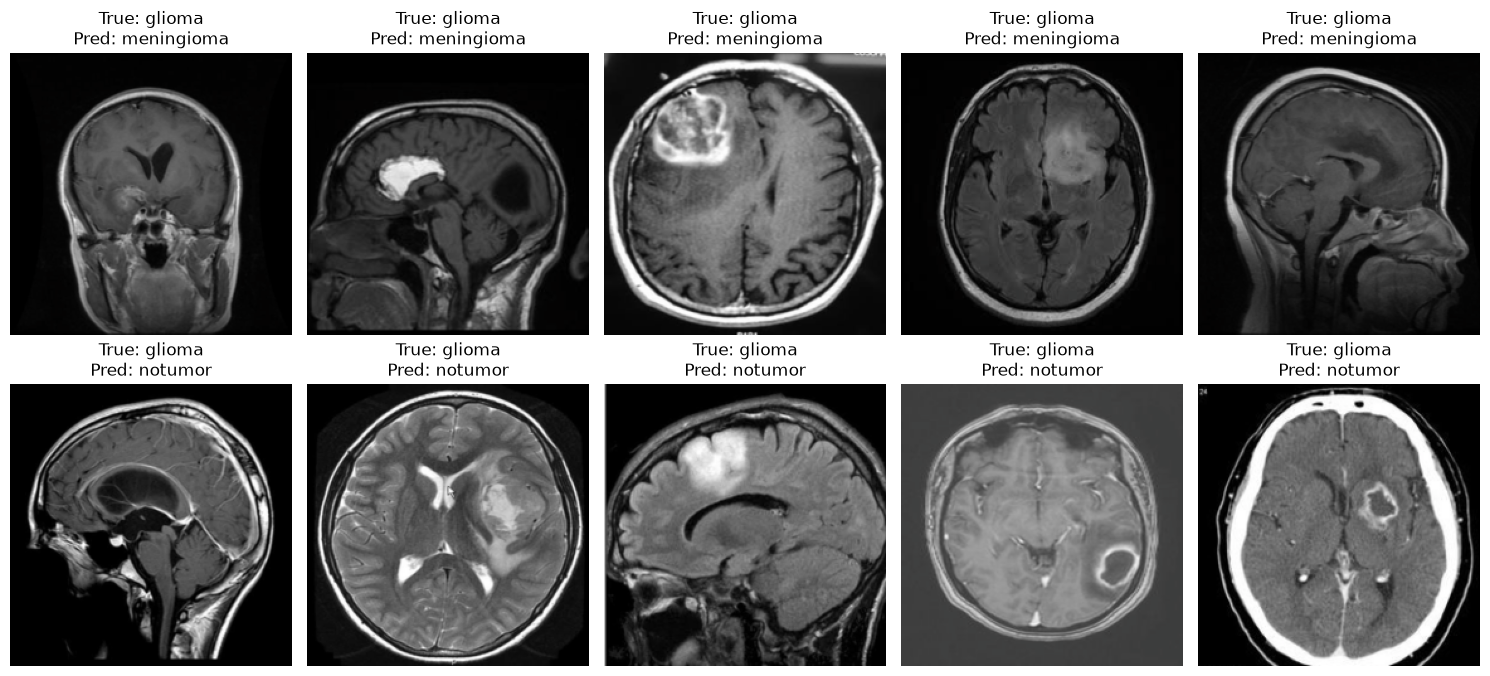

In [126]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

# Glioma → Meningioma
for ax, idx in zip(axes[0], glioma_meningioma_samples):

    image, true_label = test_dataset[idx]

    # Denormalize
    image_display = image.cpu() * std + mean
    image_display = image_display.clamp(0, 1)
    image_display = image_display.permute(1, 2, 0).numpy()

    ax.imshow(image_display)
    ax.set_title(
        f"True: glioma\nPred: meningioma"
    )
    ax.axis("off")


# Glioma → No Tumor
for ax, idx in zip(axes[1], glioma_notumor_samples):

    image, true_label = test_dataset[idx]

    # Denormalize
    image_display = image.cpu() * std + mean
    image_display = image_display.clamp(0, 1)
    image_display = image_display.permute(1, 2, 0).numpy()

    ax.imshow(image_display)
    ax.set_title(
        f"True: glioma\nPred: notumor"
    )
    ax.axis("off")


plt.tight_layout()
plt.show()

In [127]:
print("Glioma → Meningioma")
for idx in glioma_to_meningioma[:10]:
    print(idx, test_dataset.samples[idx][0])

print("\nGlioma → No Tumor")
for idx in glioma_to_notumor[:10]:
    print(idx, test_dataset.samples[idx][0])

Glioma → Meningioma
8 data\Testing\glioma\Te-gl_106.jpg
11 data\Testing\glioma\Te-gl_109.jpg
18 data\Testing\glioma\Te-gl_115.jpg
33 data\Testing\glioma\Te-gl_129.jpg
46 data\Testing\glioma\Te-gl_140.jpg
56 data\Testing\glioma\Te-gl_15.jpg
58 data\Testing\glioma\Te-gl_151.jpg
67 data\Testing\glioma\Te-gl_16.jpg
68 data\Testing\glioma\Te-gl_160.jpg
80 data\Testing\glioma\Te-gl_171.jpg

Glioma → No Tumor
5 data\Testing\glioma\Te-gl_103.jpg
38 data\Testing\glioma\Te-gl_133.jpg
49 data\Testing\glioma\Te-gl_143.jpg
66 data\Testing\glioma\Te-gl_159.jpg
74 data\Testing\glioma\Te-gl_166.jpg
75 data\Testing\glioma\Te-gl_167.jpg
132 data\Testing\glioma\Te-gl_218.jpg
197 data\Testing\glioma\Te-gl_277.jpg
198 data\Testing\glioma\Te-gl_278.jpg
235 data\Testing\glioma\Te-gl_310.jpg


In [128]:
print("Example test files:")
for path, label in test_dataset.samples[:10]:
    print(class_names[label], "->", path)

Example test files:
glioma -> data\Testing\glioma\Te-gl_1.jpg
glioma -> data\Testing\glioma\Te-gl_10.jpg
glioma -> data\Testing\glioma\Te-gl_100.jpg
glioma -> data\Testing\glioma\Te-gl_101.jpg
glioma -> data\Testing\glioma\Te-gl_102.jpg
glioma -> data\Testing\glioma\Te-gl_103.jpg
glioma -> data\Testing\glioma\Te-gl_104.jpg
glioma -> data\Testing\glioma\Te-gl_105.jpg
glioma -> data\Testing\glioma\Te-gl_106.jpg
glioma -> data\Testing\glioma\Te-gl_107.jpg


In [129]:
# create new transform
# testing 
improved_test_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# training
improved_test_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


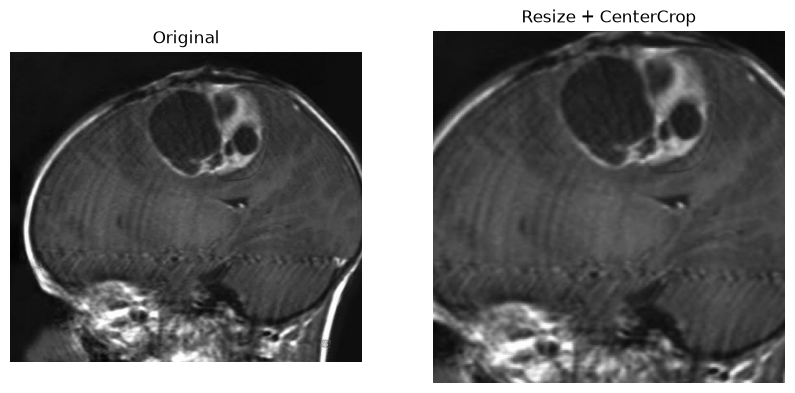

In [130]:
from PIL import Image
import matplotlib.pyplot as plt

idx = glioma_to_notumor[0]

path = test_dataset.samples[idx][0]

original = Image.open(path).convert("RGB")
processed = improved_test_transform(original)

processed_display = processed * torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1) + torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

processed_display = processed_display.clamp(0, 1)
processed_display = processed_display.permute(1, 2, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_display)
plt.title("Resize + CenterCrop")
plt.axis("off")

plt.show()

In [131]:
#test padding processing
from torchvision import transforms
from torchvision.transforms import InterpolationMode

pad_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(
        224,
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.Pad(
        padding=(0, 0, 0, 0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [132]:
# custom transform
from torchvision.transforms import functional as TF

class ResizeAndPad:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, img):

        img = img.convert("RGB")

        width, height = img.size

        scale = self.size / max(width, height)

        new_width = int(width * scale)
        new_height = int(height * scale)

        img = img.resize(
            (new_width, new_height)
        )

        pad_left = (self.size - new_width) // 2
        pad_top = (self.size - new_height) // 2
        pad_right = self.size - new_width - pad_left
        pad_bottom = self.size - new_height - pad_top

        img = TF.pad(
            img,
            [pad_left, pad_top, pad_right, pad_bottom],
            fill=0
        )

        return img

In [133]:
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image
import torch
import matplotlib.pyplot as plt

In [134]:
class ResizeAndPad:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, img):

        img = img.convert("RGB")

        width, height = img.size

        scale = self.size / max(width, height)

        new_width = int(width * scale)
        new_height = int(height * scale)

        img = img.resize(
            (new_width, new_height)
        )

        pad_left = (self.size - new_width) // 2
        pad_top = (self.size - new_height) // 2
        pad_right = self.size - new_width - pad_left
        pad_bottom = self.size - new_height - pad_top

        img = TF.pad(
            img,
            [pad_left, pad_top, pad_right, pad_bottom],
            fill=0
        )

        return img

In [135]:
pad_test_transform = transforms.Compose([
    ResizeAndPad(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("pad_test_transform created successfully")

pad_test_transform created successfully


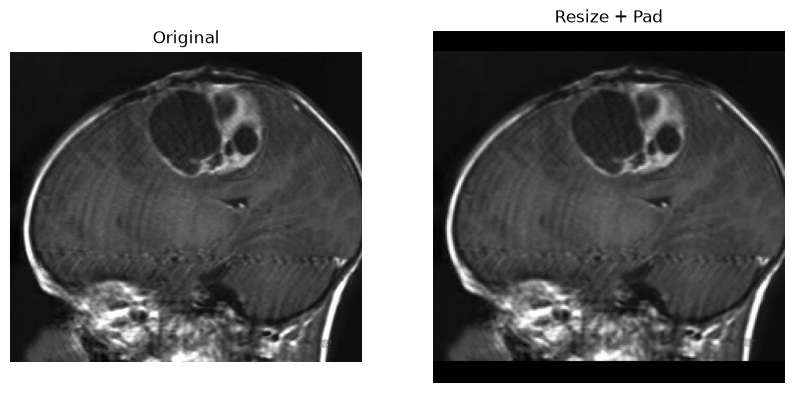

In [136]:
# visualize difficult glioma
idx = glioma_to_notumor[0]

path = test_dataset.samples[idx][0]

original = Image.open(path).convert("RGB")

processed = pad_test_transform(original)

processed_display = processed * torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1) + torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

processed_display = processed_display.clamp(0, 1)
processed_display = processed_display.permute(1, 2, 0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_display)
plt.title("Resize + Pad")
plt.axis("off")

plt.show()

In [137]:
# build resize and pad dataset
improved_train_transform = transforms.Compose([
    ResizeAndPad(224),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [138]:
# validation transfiorm
improved_val_transform = transforms.Compose([
    ResizeAndPad(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [139]:
full_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=None
)

train_dataset_improved = Subset(
    datasets.ImageFolder(
        root=train_dir,
        transform=improved_train_transform
    ),
    train_subset.indices
)

val_dataset_improved = Subset(
    datasets.ImageFolder(
        root=train_dir,
        transform=improved_val_transform
    ),
    val_subset.indices
)

In [140]:
# create dataloaders
train_loader_improved = DataLoader(
    train_dataset_improved,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader_improved = DataLoader(
    val_dataset_improved,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [141]:
print("Train:", len(train_dataset_improved))
print("Validation:", len(val_dataset_improved))

images, labels = next(iter(train_loader_improved))

print("Images:", images.shape)
print("Labels:", labels.shape)

Train: 4480
Validation: 1120
Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])


In [143]:
# freshnetset18
resnet_improved = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

resnet_improved.fc = nn.Linear(512, 4)

resnet_improved = resnet_improved.to(device)

In [144]:
# train new resnet18
resnet_improved = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

resnet_improved.fc = nn.Linear(512, 4)

resnet_improved = resnet_improved.to(device)

# Freeze everything
for param in resnet_improved.parameters():
    param.requires_grad = False

# Train only classifier
for param in resnet_improved.fc.parameters():
    param.requires_grad = True

In [145]:
# create optimizer 
criterion_improved = nn.CrossEntropyLoss()

optimizer_improved = torch.optim.Adam(
    resnet_improved.fc.parameters(),
    lr=0.001
)

In [146]:
# train stage 1
train_history_improved = []
val_history_improved = []

num_epochs = 10

best_val_acc_improved = 0.0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        resnet_improved,
        train_loader_improved,
        criterion_improved,
        optimizer_improved,
        device
    )

    val_loss, val_acc = validate(
        resnet_improved,
        val_loader_improved,
        criterion_improved,
        device
    )

    train_history_improved.append({
        "loss": train_loss,
        "acc": train_acc
    })

    val_history_improved.append({
        "loss": val_loss,
        "acc": val_acc
    })

    if val_acc > best_val_acc_improved:
        best_val_acc_improved = val_acc

        torch.save(
            resnet_improved.state_dict(),
            "models/resnet18_pad_frozen_best.pth"
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc_improved:.4f}"
)

Epoch [1/10] Train Loss: 0.6888 Train Acc: 0.7538 Val Loss: 0.4392 Val Acc: 0.8366
Epoch [2/10] Train Loss: 0.4763 Train Acc: 0.8257 Val Loss: 0.3944 Val Acc: 0.8562
Epoch [3/10] Train Loss: 0.4096 Train Acc: 0.8467 Val Loss: 0.3373 Val Acc: 0.8804
Epoch [4/10] Train Loss: 0.3946 Train Acc: 0.8587 Val Loss: 0.3303 Val Acc: 0.8732
Epoch [5/10] Train Loss: 0.3815 Train Acc: 0.8549 Val Loss: 0.3660 Val Acc: 0.8571
Epoch [6/10] Train Loss: 0.3709 Train Acc: 0.8609 Val Loss: 0.4041 Val Acc: 0.8455
Epoch [7/10] Train Loss: 0.3619 Train Acc: 0.8650 Val Loss: 0.2975 Val Acc: 0.8938
Epoch [8/10] Train Loss: 0.3694 Train Acc: 0.8647 Val Loss: 0.2975 Val Acc: 0.8911
Epoch [9/10] Train Loss: 0.3545 Train Acc: 0.8679 Val Loss: 0.3060 Val Acc: 0.8839
Epoch [10/10] Train Loss: 0.3260 Train Acc: 0.8812 Val Loss: 0.2828 Val Acc: 0.8929

Best Validation Accuracy: 0.8938


In [147]:
# mild tuning
resnet_improved.load_state_dict(
    torch.load(
        "models/resnet18_pad_frozen_best.pth",
        map_location=device
    )
)

resnet_improved = resnet_improved.to(device)

print("Best Resize + Pad ResNet18 loaded.")

Best Resize + Pad ResNet18 loaded.


In [148]:
for param in resnet_improved.layer3.parameters():
    param.requires_grad = True

for param in resnet_improved.layer4.parameters():
    param.requires_grad = True

for param in resnet_improved.fc.parameters():
    param.requires_grad = True

In [149]:
trainable_params = sum(
    p.numel()
    for p in resnet_improved.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)

Trainable parameters: 10495492


In [150]:
# fine tuneing optimizer
optimizer_improved_ft = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet_improved.parameters()
    ),
    lr=0.0001
)

In [151]:
# train
train_history_improved_ft = []
val_history_improved_ft = []

num_epochs = 10

best_val_acc_improved_ft = 0.0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        resnet_improved,
        train_loader_improved,
        criterion_improved,
        optimizer_improved_ft,
        device
    )

    val_loss, val_acc = validate(
        resnet_improved,
        val_loader_improved,
        criterion_improved,
        device
    )

    train_history_improved_ft.append({
        "loss": train_loss,
        "acc": train_acc
    })

    val_history_improved_ft.append({
        "loss": val_loss,
        "acc": val_acc
    })

    if val_acc > best_val_acc_improved_ft:

        best_val_acc_improved_ft = val_acc

        torch.save(
            resnet_improved.state_dict(),
            "models/resnet18_pad_finetuned_best.pth"
        )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc_improved_ft:.4f}"
)

Epoch [1/10] Train Loss: 0.2871 Train Acc: 0.8969 Val Loss: 0.1620 Val Acc: 0.9357
Epoch [2/10] Train Loss: 0.1221 Train Acc: 0.9589 Val Loss: 0.0909 Val Acc: 0.9670
Epoch [3/10] Train Loss: 0.0875 Train Acc: 0.9690 Val Loss: 0.0751 Val Acc: 0.9768
Epoch [4/10] Train Loss: 0.0676 Train Acc: 0.9741 Val Loss: 0.0720 Val Acc: 0.9714
Epoch [5/10] Train Loss: 0.0670 Train Acc: 0.9761 Val Loss: 0.0857 Val Acc: 0.9759
Epoch [6/10] Train Loss: 0.0331 Train Acc: 0.9884 Val Loss: 0.0448 Val Acc: 0.9866
Epoch [7/10] Train Loss: 0.0317 Train Acc: 0.9900 Val Loss: 0.0692 Val Acc: 0.9795
Epoch [8/10] Train Loss: 0.0259 Train Acc: 0.9917 Val Loss: 0.0795 Val Acc: 0.9759
Epoch [9/10] Train Loss: 0.0385 Train Acc: 0.9868 Val Loss: 0.0818 Val Acc: 0.9768
Epoch [10/10] Train Loss: 0.0304 Train Acc: 0.9906 Val Loss: 0.0787 Val Acc: 0.9768

Best Validation Accuracy: 0.9866


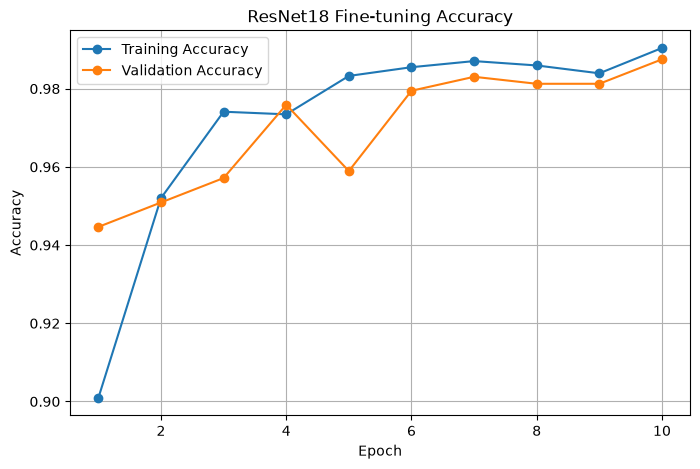

In [152]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_history_ft) + 1)

train_acc = [
    x["acc"] for x in train_history_ft
]

val_acc = [
    x["acc"] for x in val_history_ft
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Fine-tuning Accuracy")
plt.legend()
plt.grid()

plt.show()

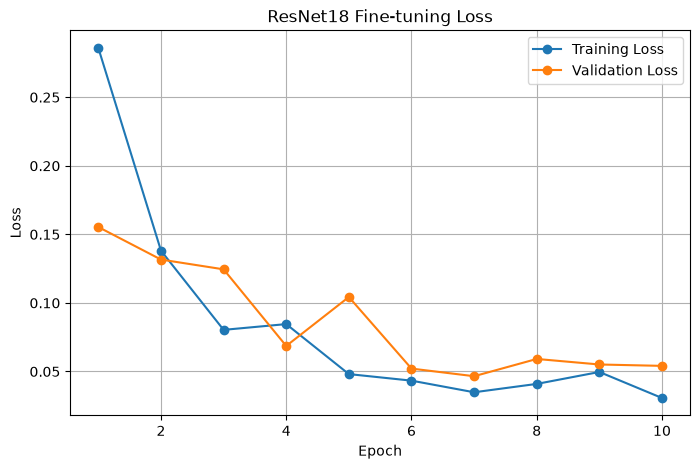

In [153]:
train_loss = [
    x["loss"] for x in train_history_ft
]

val_loss = [
    x["loss"] for x in val_history_ft
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Fine-tuning Loss")
plt.legend()
plt.grid()

plt.show()

In [154]:
import shutil

shutil.copy(
    "models/resnet18_finetuned_best.pth",
    "models/brain_tumor_resnet18_final.pth"
)

print("Final model saved.")

Final model saved.


final model evaluation


In [155]:
import torch
import torch.nn as nn
from torchvision import models

# Create ResNet18 architecture
final_model = models.resnet18(weights=None)

# Replace classifier for 4 classes
final_model.fc = nn.Linear(512, 4)

# Load best fine-tuned weights
final_model.load_state_dict(
    torch.load(
        "models/brain_tumor_resnet18_final.pth",
        map_location=device
    )
)

final_model = final_model.to(device)
final_model.eval()

print("Final model loaded successfully.")

Final model loaded successfully.


In [156]:
# genrate prediction
def predict_dataset(model, loader, device):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs, dim=1
            )

            predictions = outputs.argmax(dim=1)

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [157]:
y_true_final, y_pred_final, y_prob_final = predict_dataset(
    final_model,
    test_loader,
    device
)

print("True labels:", y_true_final.shape)
print("Predictions:", y_pred_final.shape)
print("Probabilities:", y_prob_final.shape)

True labels: (1600,)
Predictions: (1600,)
Probabilities: (1600, 4)


In [158]:
# final test accurecy
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(
    y_true_final,
    y_pred_final
)

print(
    f"Final Test Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)

Final Test Accuracy: 95.19%


In [159]:
# final classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_final,
        y_pred_final,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9881    0.8325    0.9037       400
  meningioma     0.9076    0.9825    0.9436       400
     notumor     0.9368    1.0000    0.9674       400
   pituitary     0.9851    0.9925    0.9888       400

    accuracy                         0.9519      1600
   macro avg     0.9544    0.9519    0.9508      1600
weighted avg     0.9544    0.9519    0.9508      1600



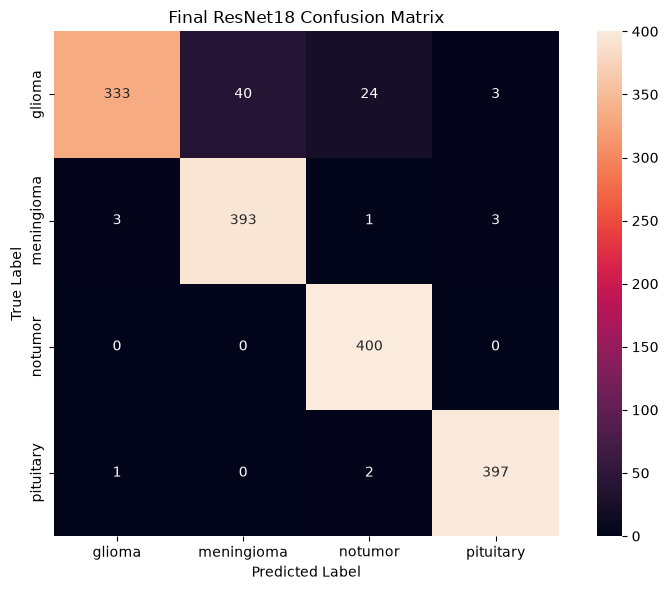

In [160]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_final = confusion_matrix(
    y_true_final,
    y_pred_final
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final ResNet18 Confusion Matrix")

plt.tight_layout()
plt.show()

In [161]:
# calculate pre class accurecy
for i, class_name in enumerate(class_names):

    correct = cm_final[i, i]
    total = cm_final[i].sum()

    accuracy = correct / total

    print(
        f"{class_name:12s}: "
        f"{accuracy * 100:.2f}%"
    )

glioma      : 83.25%
meningioma  : 98.25%
notumor     : 100.00%
pituitary   : 99.25%


In [162]:
# calculate total number of error
total_errors = np.sum(
    y_true_final != y_pred_final
)

total_samples = len(y_true_final)

print("Total test samples:", total_samples)
print("Correct predictions:", total_samples - total_errors)
print("Incorrect predictions:", total_errors)

Total test samples: 1600
Correct predictions: 1523
Incorrect predictions: 77


In [163]:
# save final matrix
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_final,
    y_pred_final,
    average="macro"
)

metrics = {
    "test_accuracy": final_accuracy,
    "macro_precision": precision,
    "macro_recall": recall,
    "macro_f1": f1
}

print(metrics)

{'test_accuracy': 0.951875, 'macro_precision': 0.9544079058313263, 'macro_recall': 0.951875, 'macro_f1': 0.9508462089457479}


In [164]:
# save matrics to JSON
import json

with open(
    "results/final_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

print("Metrics saved to results/final_metrics.json")

Metrics saved to results/final_metrics.json


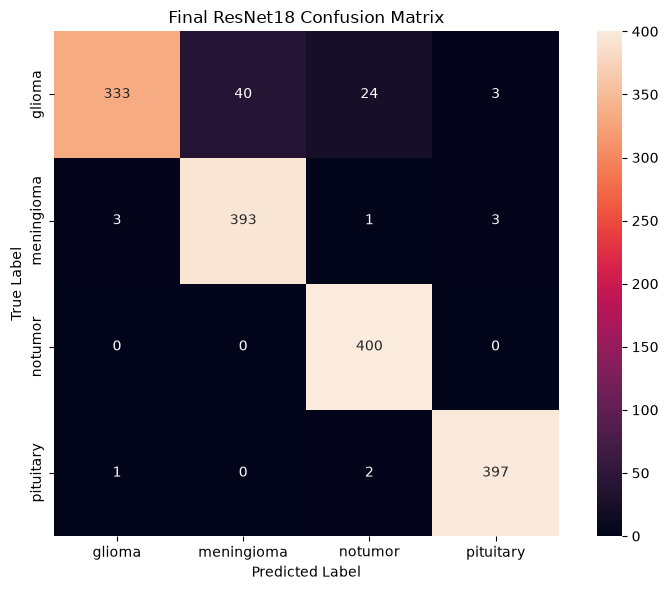

In [165]:
# save confusion matrix 
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final ResNet18 Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()